# Differential Expression: Advanced Analysis

This tutorial explores advanced differential expression (DE) analysis with Kompot, building on the [Getting Started](./01_getting_started.ipynb) tutorial.

You'll learn how to:

- Customize DE analysis parameters for your specific dataset
- Work with null gene distributions for FDR estimation
- Perform multiple comparisons and track results
- Use advanced visualization options
- Optimize computational resources

## Setup

In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import palantir
import pandas as pd
import scanpy as sc

import kompot

plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["image.cmap"] = "Spectral_r"

In [2]:
DATA_PATH = "../data/murine_bone_marrow_aging.h5ad"
GROUPING_COLUMN = "Age"
CONDITIONS = ["Young", "Old"]
CELL_TYPE_COLUMN = "highres_celltype"
DIMENSIONALITY_REDUCTION = "X_pca_harmony"
LAYER_FOR_EXPRESSION = "logged_counts"

## Load and Prepare Data

We'll reuse the dataset from the first tutorial:

In [3]:
adata = ad.read_h5ad(DATA_PATH)
palantir.utils.run_diffusion_maps(adata, pca_key="X_pca_harmony", n_components=40)
adata

/fh/fast/setty_m/user/dotto/kompot/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/fh/fast/setty_m/user/dotto/kompot/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


AnnData object with n_obs × n_vars = 8090 × 16285
    obs: 'Compartment', 'Replicate', 'Age', 'Sample', 'Info', 'batch', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden', 'phenograph', 'highres_celltype', 'midres_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Age_colors', 'Compartment_colors', 'DMEigenValues', 'Info_colors', 'README', 'Replicate_colors', 'Sample_colors', 'batch_colors', 'draw_graph', 'highres_celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'midres_celltype_colors', 'neighbors', 'pca', 'phase_colors', 'umap', 'DM_EigenValues'
    obsm: 'AbCapture', 'DM_EigenVectors', 'HTO', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_

## Understanding DE Parameters

The [kompot.de](https://kompot.readthedocs.io/en/latest/simplified.html#kompot.de) function accepts settings dataclasses for grouped parameter control:

### GP Settings (`kompot.GPSettings`)

- **`sigma`**: Noise level in the expression layer (default: 1)
  - Adjust based on your normalization method
  - Higher values for noisier data
  - Lower values for denoised data

- **`n_landmarks`**: Number of landmark points for Mahalanobis computation (default: 5000)
  - More landmarks = more accurate but slower
  - Kompot automatically uses min(n_landmarks, n_cells)

### FDR Settings (`kompot.FDRSettings`)

- **`null_genes`**: Number of permuted genes for FDR estimation (default: "auto" → 2000)
  - Higher values give better FDR estimates but increase computation time
  - Set to 0 to disable FDR computation

- **`threshold`**: FDR threshold for the `is_de` column (default: 0.05)

### Storage Settings (`kompot.StorageSettings`)

- **`result_key`**: Prefix for result field names (default: "kompot_de")
  - Change to avoid overwriting previous results

Let's run DE analysis with customized parameters:

In [4]:
de_results = kompot.de(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    gp=kompot.GPSettings(batch_size=0),  # 0 = all cells at once; increase for lower memory
    fdr=kompot.FDRSettings(null_genes=4000),
)

[2026-03-26 05:37:46,558] [INFO    ] Condition 1 (Young): 2,917 cells
[2026-03-26 05:37:46,558] [INFO    ] Condition 2 (Old): 3,116 cells
[2026-03-26 05:37:55,958] [INFO    ] Fitting expression estimator for condition 1...
[2026-03-26 05:38:15,072] [INFO    ] Fitting expression estimator for condition 2...
[2026-03-26 05:38:59,824] [INFO    ] FDR analysis complete: 879/16285 genes significantly DE at FDR < 0.05
[2026-03-26 05:38:59,826] [INFO    ] Mahalanobis distance threshold for FDR < 0.05: 10.4591
[2026-03-26 05:39:04,550] [INFO    ] This run will have `run_id=0`.


## Volcano Plot Customization

The [volcano_de](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.volcano_de) function offers extensive customization options.

### Changing the Y-Axis Metric

By default, the y-axis shows Mahalanobis distance. You can switch to local FDR:

[2026-03-26 05:39:04,989] [INFO    ] Found DE run info for run_id=-1
[2026-03-26 05:39:04,991] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2026-03-26 05:39:04,992] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info
[2026-03-26 05:39:04,993] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}
[2026-03-26 05:39:04,994] [INFO    ] Using local_fdr values for y-axis: kompot_de_Young_to_Old_mahalanobis_local_fdr
[2026-03-26 05:39:04,995] [INFO    ] Using DE run 0: comparing Young to Old
[2026-03-26 05:39:05,024] [INFO    ] Using data columns from var - lfc: 'kompot_de_Young_to_Old_mean_lfc', score: 'kompot_de_Young_to_Old_mahalanobis_local_fdr'
[2026-03-26 05:39:05,025] [INFO    ] Applied local_fdr transformation to y-axis data
[2026-03-26 05:39:05,026] [INFO    ] Significance threshold selection: using column 'kompot_de_Young_t

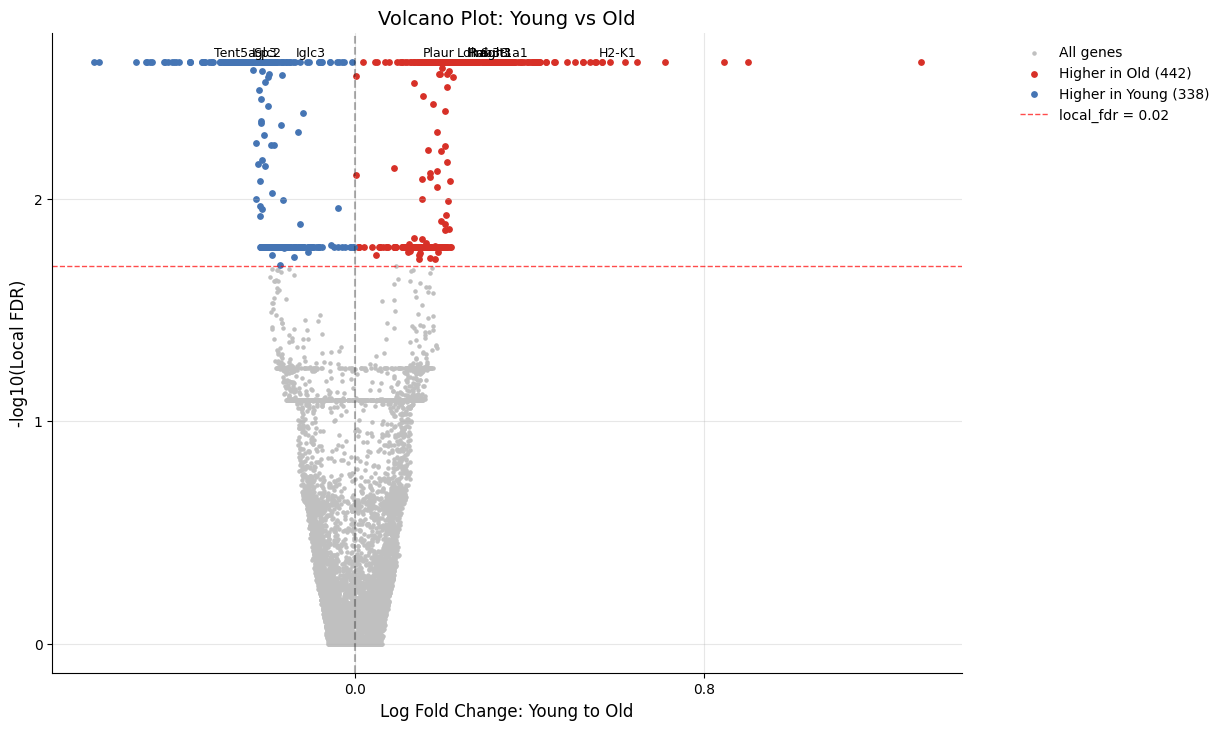

In [5]:
kompot.plot.volcano_de(
    adata,
    y_axis_type="local_fdr",
    significance_threshold=0.02,  # Adjust FDR threshold
)

### Highlighting Gene Sets

Highlight specific gene sets with custom colors and labels:

[2026-03-26 05:39:05,330] [INFO    ] Found DE run info for run_id=-1
[2026-03-26 05:39:05,331] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2026-03-26 05:39:05,332] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info
[2026-03-26 05:39:05,337] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}
[2026-03-26 05:39:05,338] [INFO    ] Using DE run 0: comparing Young to Old
[2026-03-26 05:39:05,347] [INFO    ] Using data columns from var - lfc: 'kompot_de_Young_to_Old_mean_lfc', score: 'kompot_de_Young_to_Old_mahalanobis'
[2026-03-26 05:39:05,349] [INFO    ] Added highlight group 'MHC class II' with 4 genes
[2026-03-26 05:39:05,350] [INFO    ] Added highlight group 'Antioxidant' with 6 genes
[2026-03-26 05:39:05,360] [INFO    ] Labeling 6 specific genes
[2026-03-26 05:39:05,365] [INFO    ] Skipping threshold line drawing for dicti

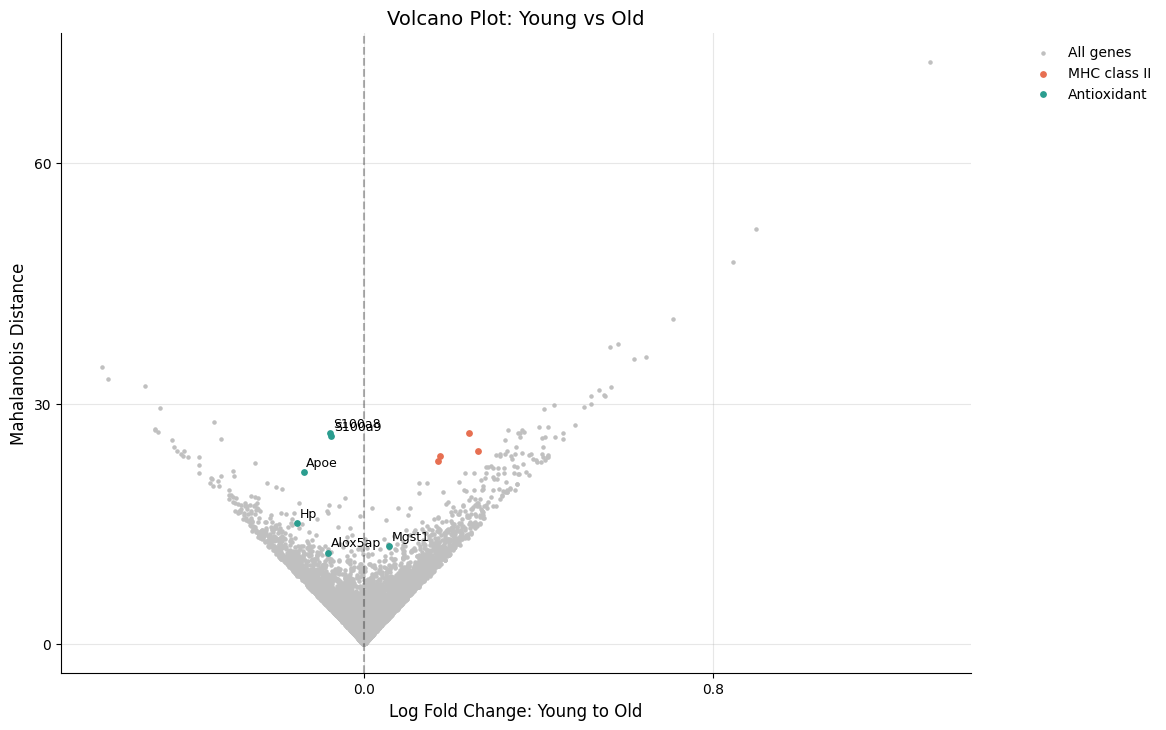

In [6]:
# Define gene sets of interest
gene_sets = [
    {
        "name": "MHC class II",
        "genes": ["H2-Ab1", "H2-Aa", "Cd74", "H2-Eb1"],
        "color": "#E76F51",
    },
    {
        "name": "Antioxidant",
        "genes": ["S100a8", "Alox5ap", "Hp", "S100a9", "Mgst1", "Apoe"],
        "color": "#2A9D8F",
    },
]

kompot.plot.volcano_de(
    adata,
    significance_threshold={"local_fdr": 0.02, "mahalanobis": 30},
    gene_labels=["S100a8", "Alox5ap", "Hp", "S100a9", "Mgst1", "Apoe"],
    highlight_genes=gene_sets,
)

`gene_labels` can be:
- A list of gene names
- A dictionary mapping gene names to custom labels
- An integer to auto-select the top N genes

`highlight_genes` can be:
- A list of gene names (all same color)
- A list of dictionaries with "name", "genes", and "color" keys (as shown)
- An integer to highlight the top N genes

### Plotting Individual Genes

Imputed expression for each condition is stored in `adata.layers`:
- `kompot_de_Young_imputed`
- `kompot_de_Old_imputed`
- `kompot_de_Young_to_Old_fold_change`

You can plot these manually:
```Python
gene = "Igkc"

# Manual plotting
sc.pl.embedding(adata, basis="umap", color=gene, layer="logged_counts")
sc.pl.embedding(adata, basis="umap", color=gene, layer="kompot_de_Young_imputed")
sc.pl.embedding(adata, basis="umap", color=gene, layer="kompot_de_Old_imputed")
sc.pl.embedding(adata, basis="umap", color=gene, layer="kompot_de_Young_to_Old_fold_change")
```
Or use the convenience function:

[2026-03-26 05:39:05,582] [INFO    ] Found DE run info for run_id=-1
[2026-03-26 05:39:05,583] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2026-03-26 05:39:05,584] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info
[2026-03-26 05:39:05,585] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}
[2026-03-26 05:39:05,586] [INFO    ] Using DE run 0: comparing Young to Old
[2026-03-26 05:39:05,587] [INFO    ] Using fields for gene expression plot - lfc_key: 'kompot_de_Young_to_Old_mean_lfc', score_key: 'kompot_de_Young_to_Old_mahalanobis'
[2026-03-26 05:39:05,587] [INFO    ] Using layer 'logged_counts' inferred from run information
[2026-03-26 05:39:05,590] [INFO    ] Using imputed layer 'kompot_de_Young_imputed' for 'Young'
[2026-03-26 05:39:05,592] [INFO    ] Using imputed layer 'kompot_de_Old_imputed' for 'Old'
[2026-03-26 05:

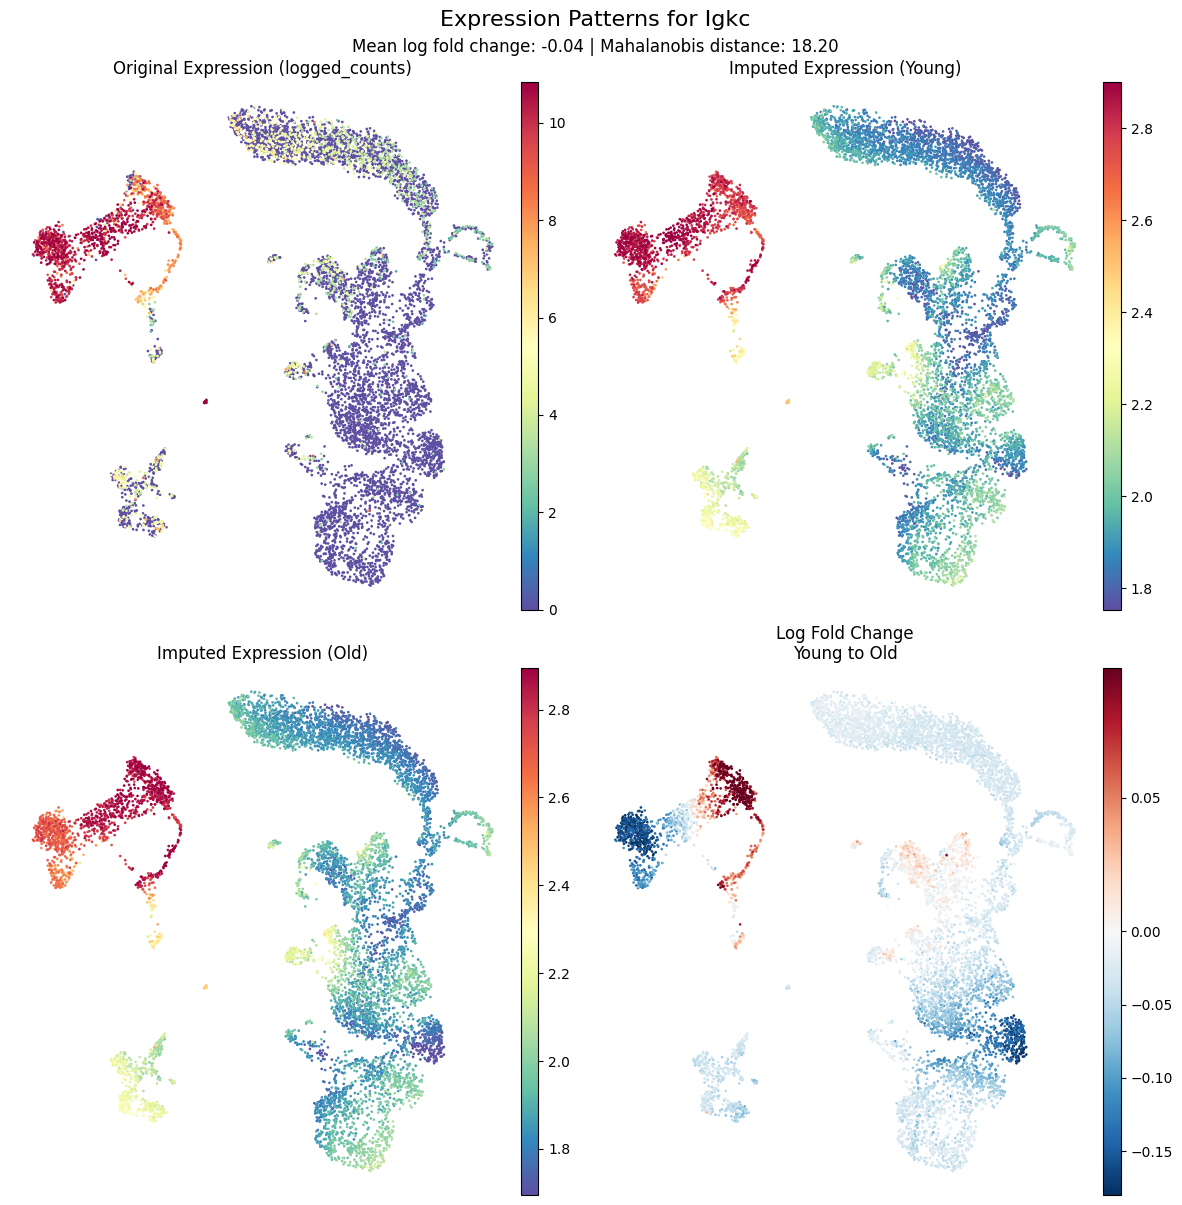

In [7]:
kompot.plot.plot_gene_expression(
    adata, gene="Igkc", vmin="p2", vmax="p98", frameon=False
)

### Comparing Conditions with Subplots

The [kompot.plot.embedding](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.embedding) wrapper supports filtering to specific groups:

[2026-03-26 05:39:06,406] [INFO    ] Selected 2,917 cells out of 8,090 total cells.
[2026-03-26 05:39:06,512] [INFO    ] Selected 3,116 cells out of 8,090 total cells.


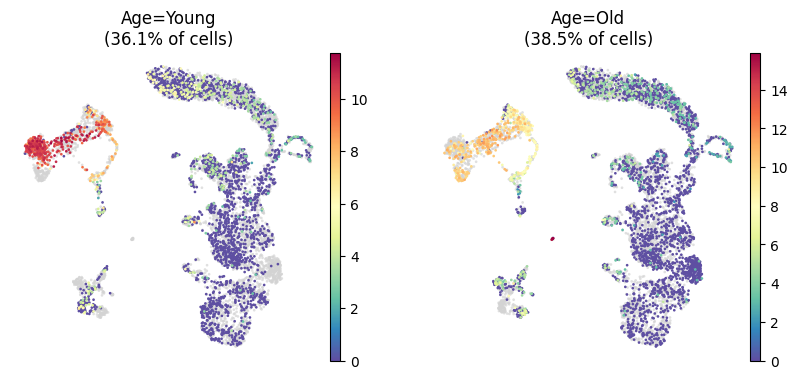

In [8]:
kompot.plot.embedding(
    adata,
    "umap",
    color="Igkc",
    layer=LAYER_FOR_EXPRESSION,
    frameon=False,
    mgroups=[{GROUPING_COLUMN: condition} for condition in CONDITIONS],
)

The `mgroups` parameter creates multiple subplots, each showing cells filtered by the specified conditions.

## Heatmap Customization

The [heatmap](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.heatmap) function visualizes average expression per group.

### Z-Score Normalization

By default, values are z-scored across conditions for each gene. Disable this to show raw expression:

[2026-03-26 05:39:06,875] [INFO    ] Found DE run info for run_id=-1
[2026-03-26 05:39:06,876] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info
[2026-03-26 05:39:06,879] [INFO    ] Successfully inferred fields: {'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}
[2026-03-26 05:39:06,880] [INFO    ] Using DE run 0 for heatmap.
[2026-03-26 05:39:06,881] [INFO    ] Inferred score_key='kompot_de_Young_to_Old_mahalanobis' from run information
[2026-03-26 05:39:06,887] [INFO    ] Inferred condition_column='Age' from run information
[2026-03-26 05:39:06,888] [INFO    ] Inferred condition1='Young' from run information
[2026-03-26 05:39:06,888] [INFO    ] Inferred condition2='Old' from run information
[2026-03-26 05:39:06,889] [INFO    ] Inferred layer='logged_counts' from run information
[2026-03-26 05:39:06,889] [INFO    ] Creating split heatmap with 20 genes/features
[2026-03-26 05:39:06,890] [INFO    ] Using expression data from layer: 'logged_counts

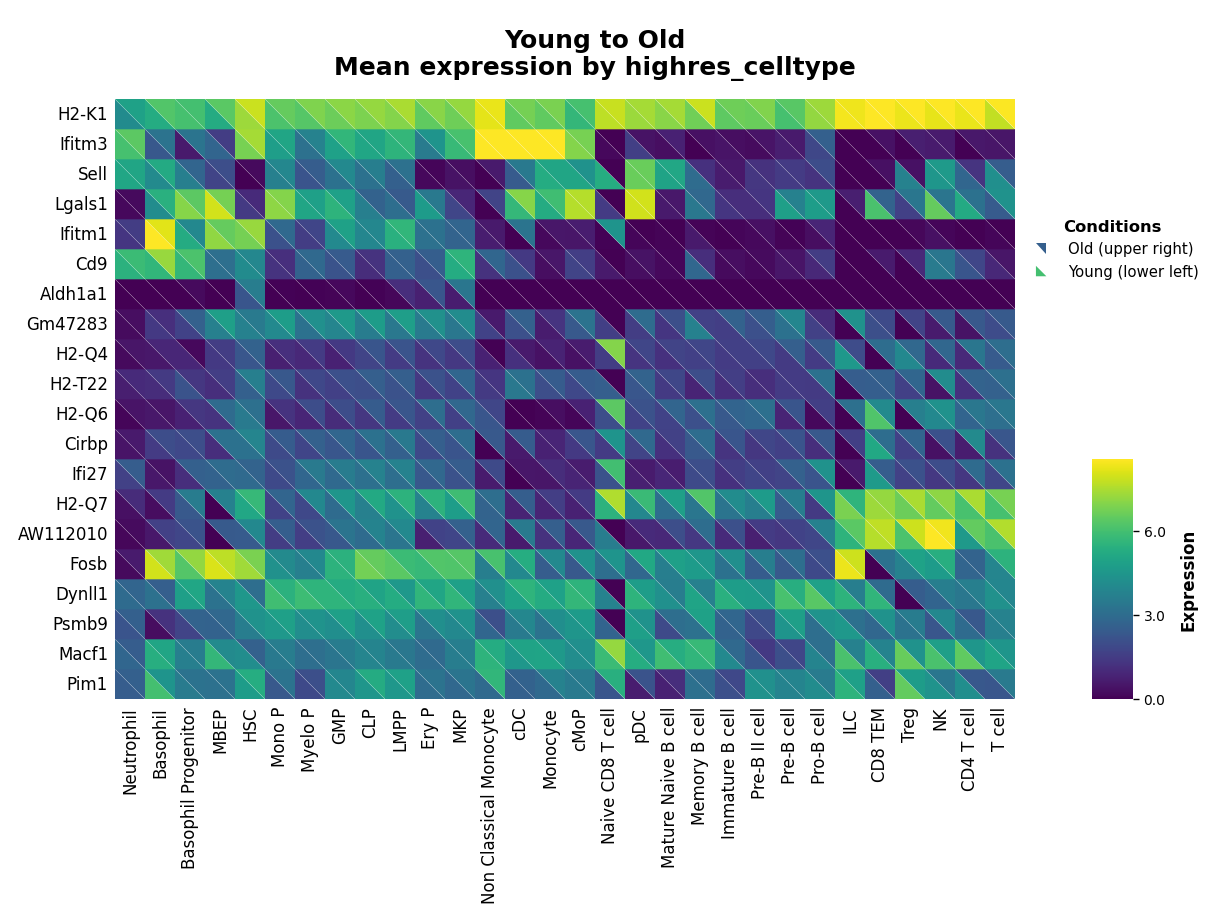

In [9]:
kompot.plot.heatmap(
    adata,
    n_top_genes=20,
    groupby=CELL_TYPE_COLUMN,
    exclude_groups="Plasma cell",
    standard_scale=None,  # Disable z-scoring
    vmax="p99",
)

### Custom Gene Lists

Instead of selecting top genes by Mahalanobis distance, provide a custom list:

[2026-03-26 05:39:08,550] [INFO    ] Inferred condition_column='Age' from run information
[2026-03-26 05:39:08,551] [INFO    ] Inferred condition1='Young' from run information
[2026-03-26 05:39:08,552] [INFO    ] Inferred condition2='Old' from run information
[2026-03-26 05:39:08,553] [INFO    ] Inferred layer='logged_counts' from run information
[2026-03-26 05:39:08,554] [INFO    ] Creating split heatmap with 7 genes/features
[2026-03-26 05:39:08,555] [INFO    ] Using expression data from layer: 'logged_counts'
[2026-03-26 05:39:08,620] [INFO    ] Excluded 7 cells from groups: Plasma cell
[2026-03-26 05:39:08,626] [INFO    ] Applying gene-wise z-scoring (standard_scale='var')


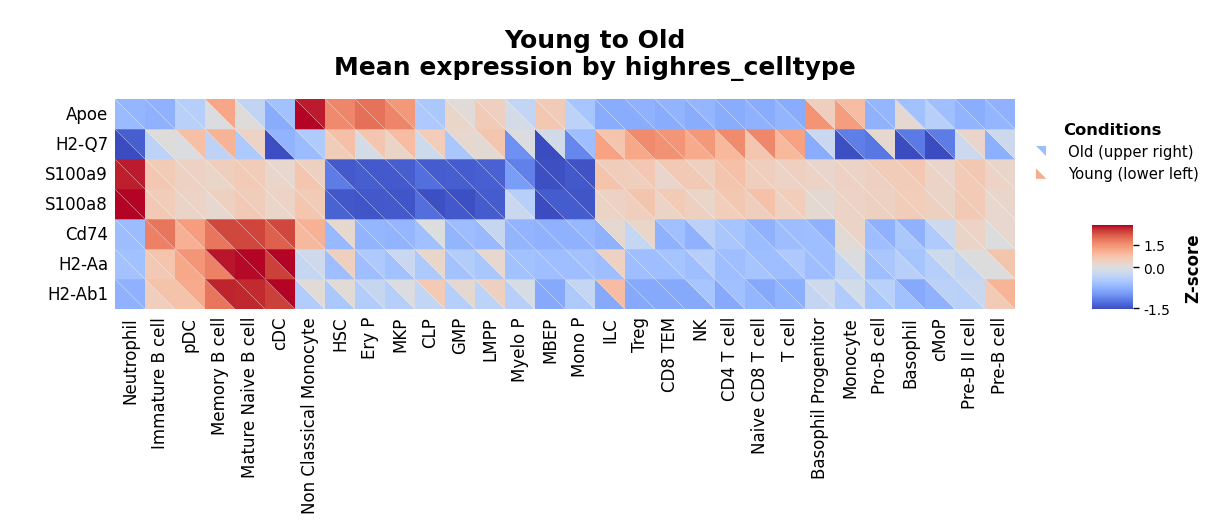

In [10]:
custom_genes = ["H2-Q7", "Cd74", "H2-Aa", "H2-Ab1", "S100a9", "S100a8", "Apoe"]

kompot.plot.heatmap(
    adata,
    genes=custom_genes,
    groupby=CELL_TYPE_COLUMN,
    exclude_groups="Plasma cell",
    vmin="p1",
    vmax="p99",
)

### Simplify Heatmap Display

To simplify the plot, pass `fold_change_mode=True`. Each square will then represent only the difference between the two groups, which equals the log fold change if the expression data was log-transformed.

[2026-03-26 05:39:09,262] [INFO    ] Inferred condition_column='Age' from run information
[2026-03-26 05:39:09,264] [INFO    ] Inferred condition1='Young' from run information
[2026-03-26 05:39:09,265] [INFO    ] Inferred condition2='Old' from run information
[2026-03-26 05:39:09,266] [INFO    ] Inferred layer='logged_counts' from run information
[2026-03-26 05:39:09,266] [INFO    ] Creating fold change heatmap with 7 genes/features
[2026-03-26 05:39:09,268] [INFO    ] Using expression data from layer: 'logged_counts'
[2026-03-26 05:39:09,332] [INFO    ] Excluded 7 cells from groups: Plasma cell
[2026-03-26 05:39:09,339] [INFO    ] Applying gene-wise z-scoring (standard_scale='var')
[2026-03-26 05:39:09,383] [WARNING ] standard_scale is ignored in fold_change_mode as z-scoring is not appropriate for fold changes


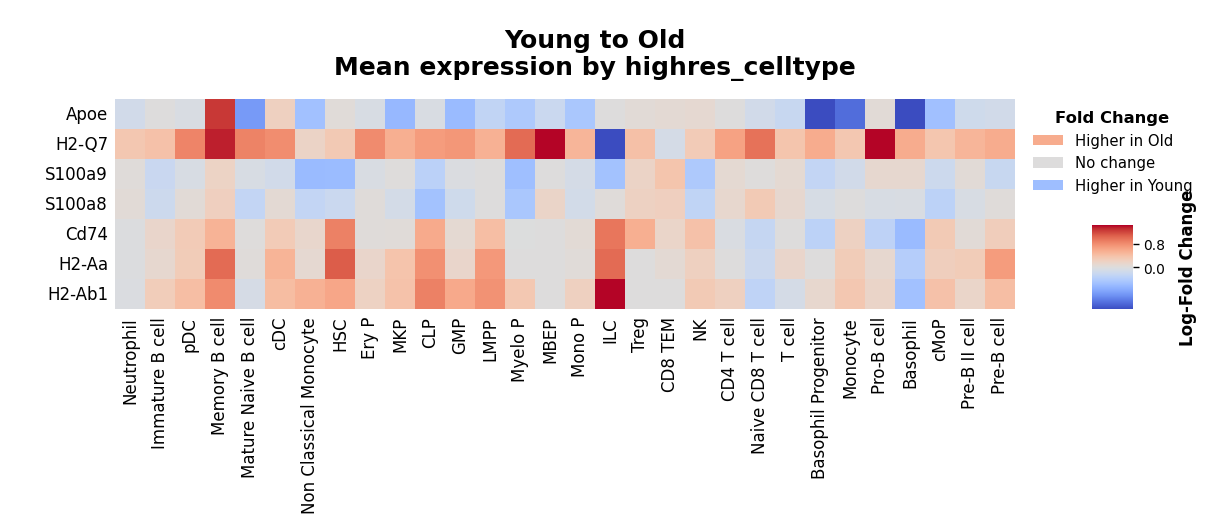

In [11]:
kompot.plot.heatmap(
    adata,
    genes=custom_genes,
    groupby=CELL_TYPE_COLUMN,
    exclude_groups="Plasma cell",
    vmin="p1",
    vmax="p99",
    fold_change_mode=True,
)

## Dotplot Customization

The [dotplot](https://kompot.readthedocs.io/en/latest/plotting.html#kompot.plot.dotplot) function renders the same per-group fold-change summary as `kompot.plot.heatmap` but adds a second encoding dimension: dot **color** is the mean per-cell LFC (like `heatmap(fold_change_mode=True)`), and dot **size** is the fraction of cells in each category whose expression exceeds a threshold. Both encodings come from the same kompot DE run.

It also accepts externally-provided axes (`axes=(main, cbar, size_legend)`), so it composes cleanly into figure-level layouts where `scanpy.pl.DotPlot`'s built-in GridSpec would fight back.

### Auto-pick top genes by Mahalanobis

With `genes=None`, the top `n_top` genes are picked by the Mahalanobis column inferred from the latest kompot DE run — same default as `heatmap`:

In [ ]:
categories = [
    c for c in adata.obs[CELL_TYPE_COLUMN].cat.categories
    if c != "Plasma cell"
]

kompot.plot.dotplot(
    adata,
    genes=None,
    groupby=CELL_TYPE_COLUMN,
    categories_order=categories,
    n_top=15,
)

### Custom gene list

Pass an explicit `genes` list when you want to match a specific comparison or reproduce a figure — same shape as `heatmap`:

In [ ]:
kompot.plot.dotplot(
    adata,
    genes=custom_genes,
    groupby=CELL_TYPE_COLUMN,
    categories_order=categories,
)

### Adjusting the color scale and size encoding

The color scale is symmetric around 0 keyed on the `vabs_pct`-th percentile of `|LFC|` by default. Tighten the scale when a few outlier genes compress the visible dynamic range, and tune `size_exponent` / `dot_max` to emphasise fraction-expressing differences:

In [ ]:
kompot.plot.dotplot(
    adata,
    genes=custom_genes,
    groupby=CELL_TYPE_COLUMN,
    categories_order=categories,
    vabs_pct=90,        # tighter color scale
    size_exponent=2.0,   # stronger fraction-expressing emphasis
    dot_max=80,
)

## Multiple Comparisons

Kompot tracks multiple analysis runs, allowing you to perform different comparisons on the same dataset.

### Running Additional Comparisons

Let's add a comparison between Young and Mid-age mice (if Mid exists in your data):

In [12]:
de_results_2 = kompot.de(
    adata,
    groupby=GROUPING_COLUMN,
    condition1="Young",
    condition2="Mid",
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    gp=kompot.GPSettings(batch_size=0),
)

[2026-03-26 05:39:09,955] [WARNING ] Differential expression results with result_key='kompot_de' already exist in the dataset. Previous run was at 2026-03-26T05:39:04.524253 comparing Young to Old. Fields that will be overwritten: layers.kompot_de_Young_imputed, obs.kompot_de_Young_std Set overwrite=False to prevent overwriting or overwrite=True to silence this message.
[2026-03-26 05:39:09,958] [INFO    ] Condition 1 (Young): 2,917 cells
[2026-03-26 05:39:09,959] [INFO    ] Condition 2 (Mid): 2,057 cells
[2026-03-26 05:39:11,315] [INFO    ] Fitting expression estimator for condition 1...
[2026-03-26 05:39:11,532] [WARNING ] Gaussin process type is GaussianProcessType.FIXED and n_landmarks=5,000 are requested while only 2,917 datapoints are available. Using all datapoints for 2,917 landmarks instead.
[2026-03-26 05:39:13,733] [INFO    ] Fitting expression estimator for condition 2...
[2026-03-26 05:39:16,683] [WARNING ] Gaussin process type is GaussianProcessType.FIXED and n_landmarks=

Kompot warns about field overwrites and tracks which run created each field.

### Accessing Different Runs

Each analysis is assigned a `run_id` (0 for the first run, 1 for the second, etc.). Most plotting functions accept a `run_id` parameter:

[2026-03-26 05:39:38,694] [INFO    ] Found DE run info for run_id=0
[2026-03-26 05:39:38,695] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2026-03-26 05:39:38,696] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info
[2026-03-26 05:39:38,697] [WARNING ] Field 'kompot_de_Young_to_Old_mean_lfc' was last written by run 0, but current context expects run 1. The field may have been overwritten.
[2026-03-26 05:39:38,698] [WARNING ] Field 'kompot_de_Young_to_Old_mahalanobis' was last written by run 0, but current context expects run 1. The field may have been overwritten.
[2026-03-26 05:39:38,699] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}
[2026-03-26 05:39:38,700] [WARNING ] Field inference completed with 2 warnings
[2026-03-26 05:39:38,700] [INFO    ] Using DE run 0: comparing Young to Old
[2026-03-26 05:39:38,710] [INFO 

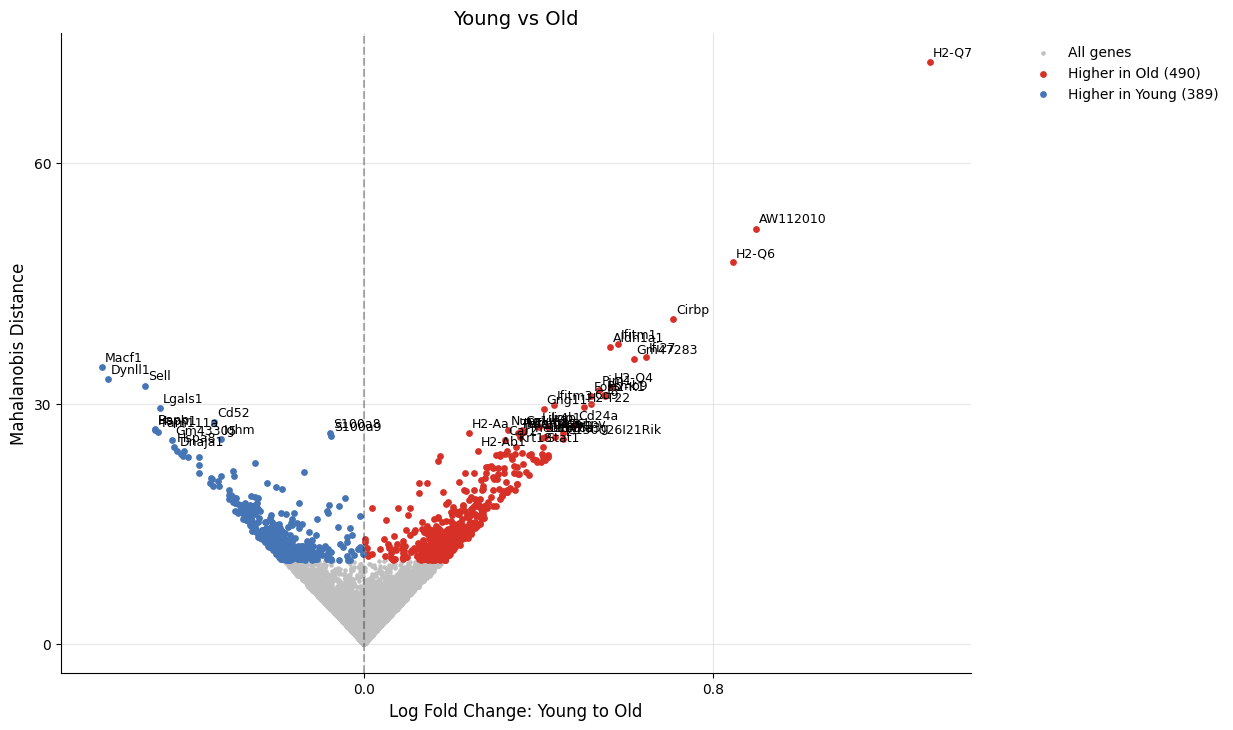

In [13]:
# Plot the first comparison (Young vs Old)
kompot.plot.volcano_de(adata, run_id=0, title="Young vs Old", gene_labels=50)

[2026-03-26 05:39:39,103] [INFO    ] Found DE run info for run_id=0
[2026-03-26 05:39:39,104] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2026-03-26 05:39:39,105] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info
[2026-03-26 05:39:39,106] [WARNING ] Field 'kompot_de_Young_to_Old_mean_lfc' was last written by run 0, but current context expects run 1. The field may have been overwritten.
[2026-03-26 05:39:39,108] [WARNING ] Field 'kompot_de_Young_to_Old_mahalanobis' was last written by run 0, but current context expects run 1. The field may have been overwritten.
[2026-03-26 05:39:39,108] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}
[2026-03-26 05:39:39,109] [WARNING ] Field inference completed with 2 warnings
[2026-03-26 05:39:39,110] [INFO    ] Using DE run 0: comparing Young to Old
[2026-03-26 05:39:39,110] [INFO 

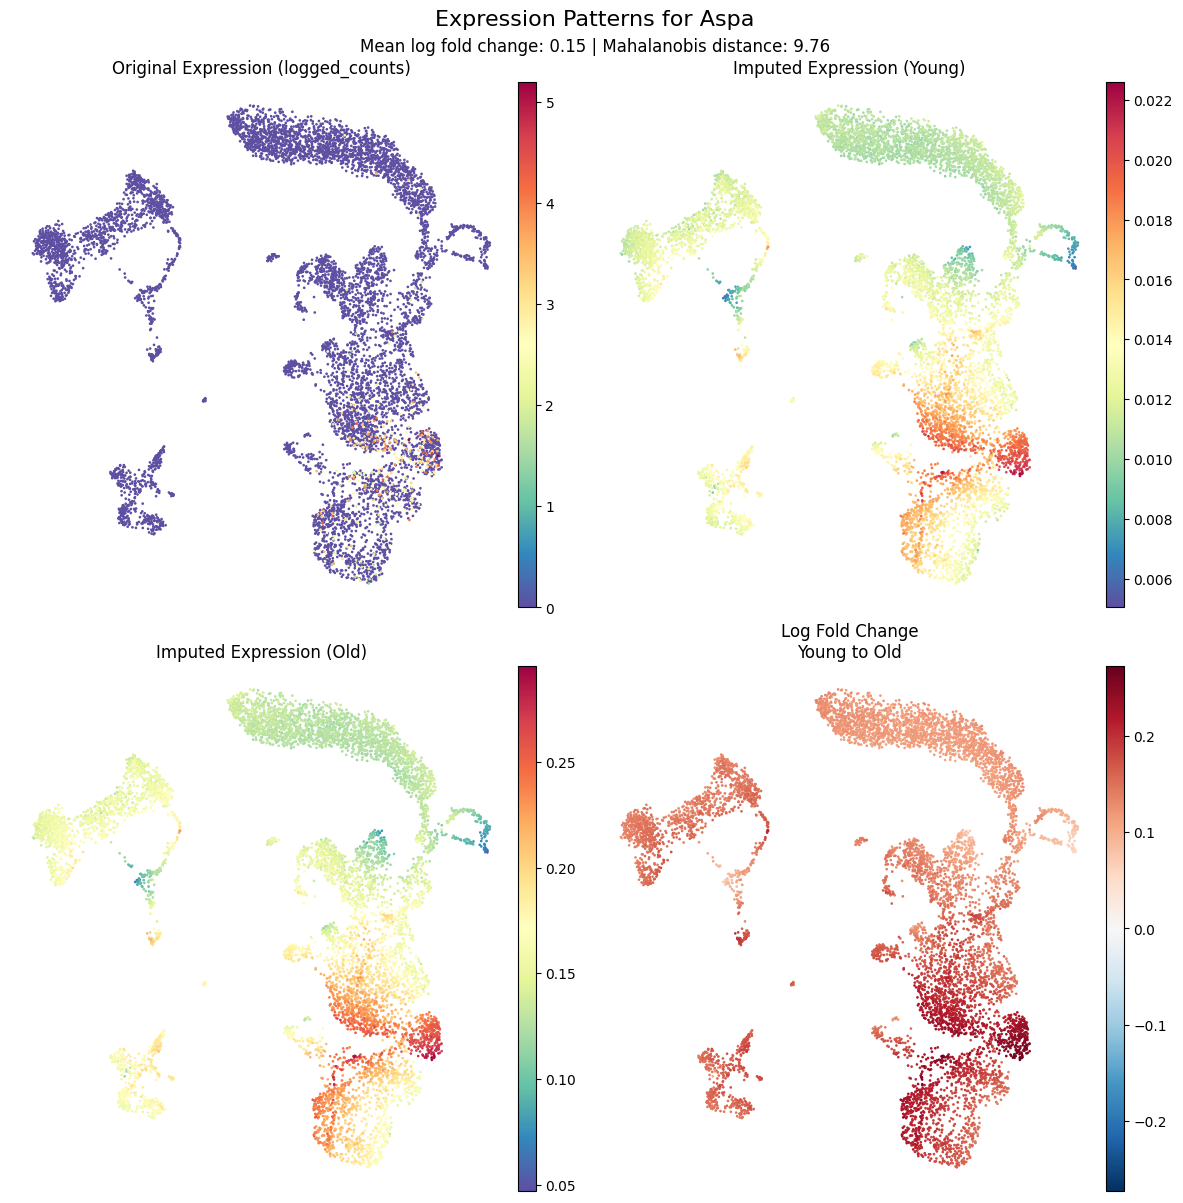

In [14]:
kompot.plot.plot_gene_expression(
    adata, run_id=0, gene="Aspa", frameon=False
)

[2026-03-26 05:39:39,915] [INFO    ] Found DE run info for run_id=1
[2026-03-26 05:39:39,917] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Mid_mean_lfc' from run info
[2026-03-26 05:39:39,918] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Mid_mahalanobis' from run info
[2026-03-26 05:39:39,919] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Mid_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Mid_mahalanobis'}
[2026-03-26 05:39:39,920] [INFO    ] Using DE run 1: comparing Young to Mid
[2026-03-26 05:39:39,930] [INFO    ] Using data columns from var - lfc: 'kompot_de_Young_to_Mid_mean_lfc', score: 'kompot_de_Young_to_Mid_mahalanobis'
[2026-03-26 05:39:39,935] [INFO    ] Highlighting 626 genes marked as DE (253 up, 373 down)
[2026-03-26 05:39:39,948] [INFO    ] Labeling top 10 genes by score


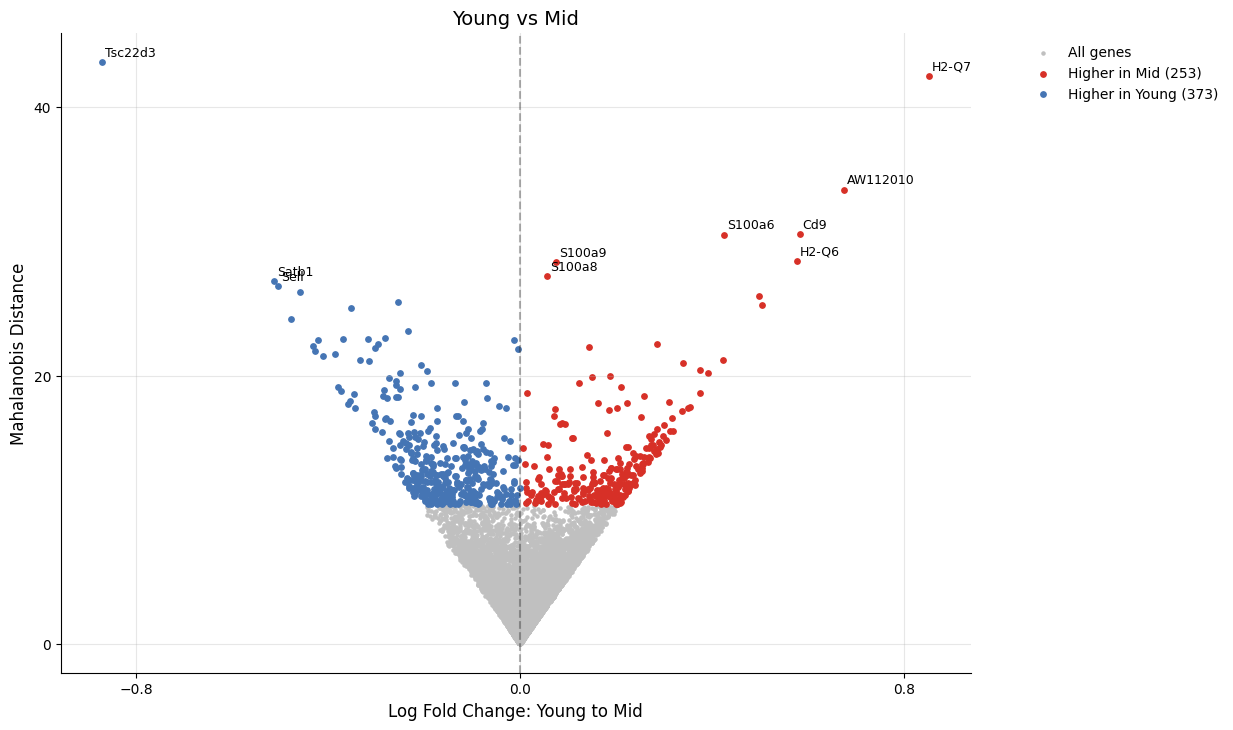

In [15]:
# Plot the second comparison (Young vs Mid)
kompot.plot.volcano_de(adata, run_id=1, title="Young vs Mid")

[2026-03-26 05:39:40,191] [INFO    ] Found DE run info for run_id=-1
[2026-03-26 05:39:40,193] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Mid_mean_lfc' from run info
[2026-03-26 05:39:40,194] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Mid_mahalanobis' from run info
[2026-03-26 05:39:40,196] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Mid_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Mid_mahalanobis'}
[2026-03-26 05:39:40,197] [INFO    ] Using DE run 1: comparing Young to Mid
[2026-03-26 05:39:40,198] [INFO    ] Using fields for gene expression plot - lfc_key: 'kompot_de_Young_to_Mid_mean_lfc', score_key: 'kompot_de_Young_to_Mid_mahalanobis'
[2026-03-26 05:39:40,198] [INFO    ] Using layer 'logged_counts' inferred from run information
[2026-03-26 05:39:40,200] [INFO    ] Using imputed layer 'kompot_de_Young_imputed' for 'Young'
[2026-03-26 05:39:40,201] [INFO    ] Using imputed layer 'kompot_de_Mid_imputed' for 'Mid'
[2026-03-26 05:

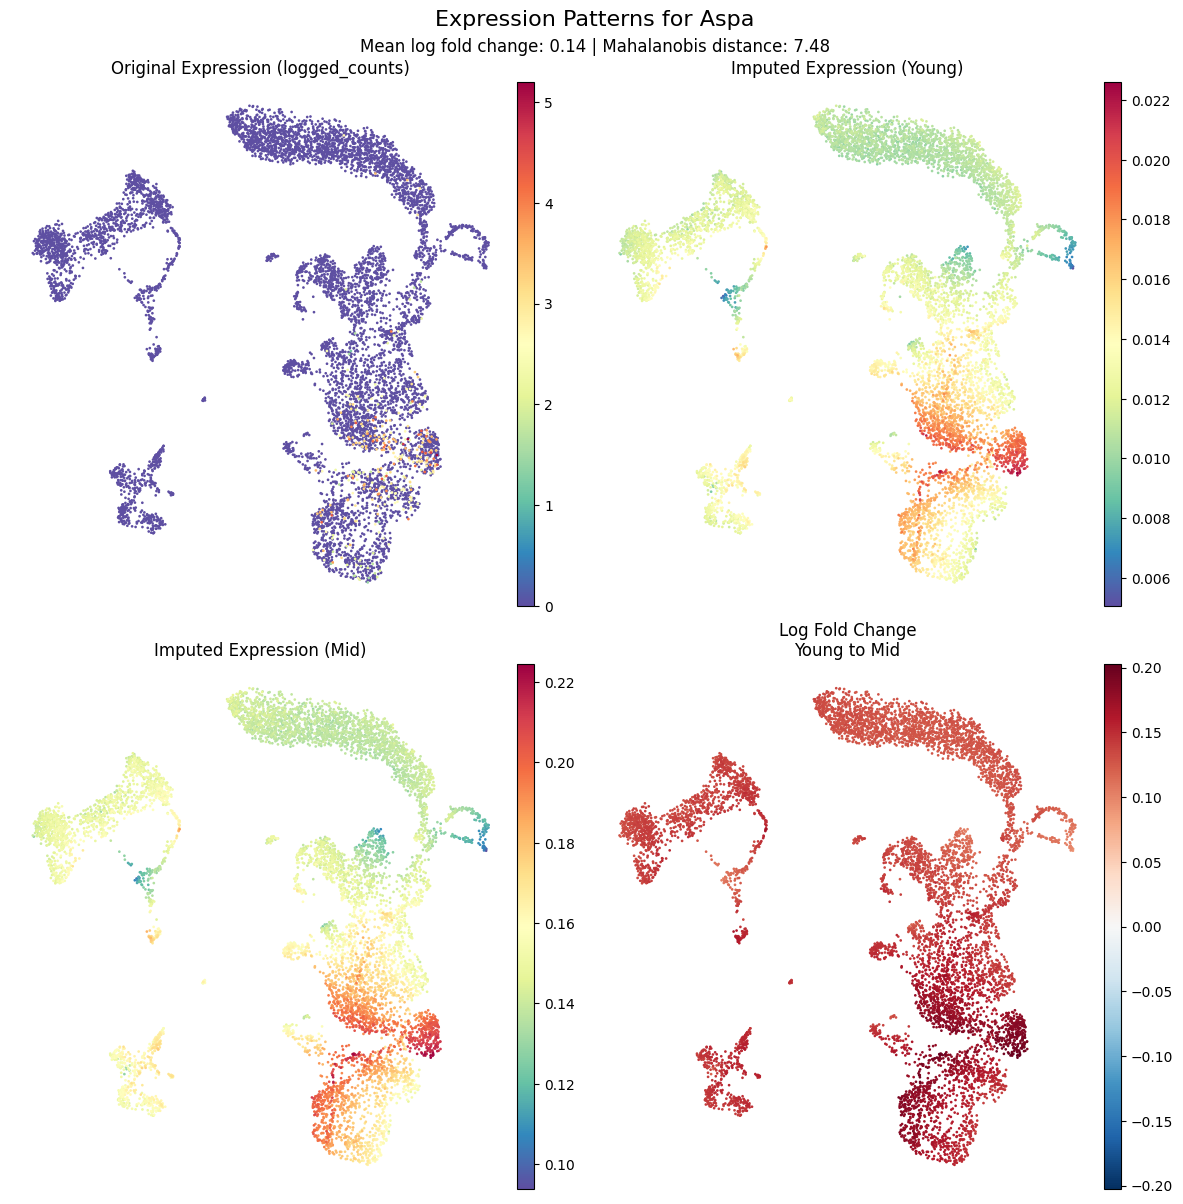

In [16]:
kompot.plot.plot_gene_expression(
    adata, gene="Aspa", frameon=False
)

You can also use negative indexing (`run_id=-1` for the most recent run).

### Inspecting Run Metadata

The [RunInfo](https://kompot.readthedocs.io/en/latest/anndata.html#kompot.anndata.utils.RunInfo) utility provides detailed information about each analysis. Here we inspect the first run to see that some data has been overwritten by the most recent one:

In [17]:
run_info = kompot.RunInfo(adata, run_id=0, analysis_type="de")
run_info

Parameter,Value
conditions,Young to Old
obsm_key,X_pca_harmony
uses_sample_variance,False
layer,logged_counts
timestamp,2026-03-27T00:41:42.174094
Fields Created,9
Parameter,Value
groupby,Age
condition1,Young
condition2,Old


### Comparing Runs

Compare parameters between two runs:

In [18]:
kompot.RunInfo(adata, run_id=0, analysis_type="de").compare_with(1)

RunComparison(run1=0, run2=1, same_fields=2, different_params=2)

### Reproducing and Editing Runs

Every run stores its parameters as Settings objects. Use `call_args()` to get a kwargs dict that can reproduce the run, or edit it first:

In [19]:
kwargs = run_info.call_args()

# Tweak parameters before re-running
kwargs["fdr"].threshold = 0.01          # tighten FDR
kwargs["condition2"] = "Mid"            # different comparison
kwargs["gp"].n_landmarks = 3000         # fewer landmarks

# kompot.de(adata, **kwargs) # reproduce de run with similar parameters

## Resource Planning

For large datasets, pass `dry_run=True` to estimate resource requirements before running the full analysis:

In [19]:
plan = kompot.de(
    adata,
    groupby=GROUPING_COLUMN,
    condition1="Young",
    condition2="Old",
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    fdr=kompot.FDRSettings(null_genes=2000),
    dry_run=True,
)

RESOURCE USAGE PLAN

System Resources:
  Memory: 316.82 GB available (of 754.59 GB total)
  Disk:   377.28 GB available at /tmp

Total Requirements:
  Memory: 31.76 GB (10% of available)

Memory Allocations:
  • Mellon precision matrix L (condition 1, 2,917/3,116 cells) (np.int64(2917), np.int64(2917)): 64.92 MB
  • Mellon precision matrix L (condition 2, 2,917/3,116 cells) (np.int64(3116), np.int64(3116)): 74.08 MB
  • Imputed expression (condition 1) (8090, 18285): 1.10 GB → adata.layers['kompot_de_Young_imputed']
  • Imputed expression (condition 2) (8090, 18285): 1.10 GB → adata.layers['kompot_de_Old_imputed']
  • Fold change (8090, 18285): 1.10 GB → adata.layers['kompot_de_Young_to_Old_fold_change']
  • Temporary matrices during predictions (batch_size=100) (100, 5000) + (100, 18285): 17.77 MB
  • Peak intermediate arrays during predictions (~25 arrays) 25×(8090, 18285): 27.55 GB
  • Function predictor covariances (per condition) (5000, 5000): 381.47 MB
  • Combined covariance mat

The report shows:
- Available system memory and disk space
- Estimated memory requirements for each computation step
- Which fields will be created or overwritten (with `run_id`)
- Whether the analysis is feasible

This is especially useful for testing different parameter combinations (e.g., with/without sample variance) before committing to a long computation.

## Saving Results

### Selective Cleanup

Remove imputed expression layers while preserving statistical results:

To clean up specific runs only:

## Summary

This tutorial covered:

✓ Customizing DE parameters (`null_genes`, `sigma`, `batch_size`)  
✓ Advanced volcano plot options  
✓ Expression visualization techniques  
✓ Heatmap customization  
✓ Managing multiple comparisons with `run_id`  
✓ Resource planning with dry runs  

### Next Steps

- **Tutorial 3**: [Sample Variance Analysis](./03_sample_variance.ipynb) - Account for biological replicates
- **API Documentation**: [kompot.readthedocs.io](https://kompot.readthedocs.io)